In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

### EDA

In [2]:
df = pd.read_csv("../../datasets/dataset/train.csv")

In [3]:
print("length of dataset: ", len(df))
print("Labels distribution: ", df['label'].value_counts(normalize=True) * 100)
print("Total missing values: ", df.isnull().sum().sum())

length of dataset:  40000
Labels distribution:  label
0    96.8
1     3.2
Name: proportion, dtype: float64
Total missing values:  153603


We can observe that the data is skewed for target = 0. Means, most people do not click on the adds :) .

In [7]:
from pandas.core.arrays import categorical


train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
train_df = train_df.copy()
val_df = val_df.copy()

dense_cols = [f"integer_feature_{i}" for i in range(1, 14)]
categorical_cols = [f"categorical_feature_{i}" for i in range(1, 27)]

train_df[dense_cols] = train_df[dense_cols].fillna(0)
val_df[dense_cols] = val_df[dense_cols].fillna(0)
train_df[categorical_cols] = train_df[categorical_cols].fillna('UNK')
val_df[categorical_cols] = val_df[categorical_cols].fillna('UNK')

for col in dense_cols:
    train_df[col] = np.log(1 + train_df[col] - train_df[col].min() + 1)
    val_df[col] = np.log(1 + val_df[col] - val_df[col].min() + 1)



scaler = MinMaxScaler()
train_df[dense_cols] = scaler.fit_transform(train_df[dense_cols])
val_df[dense_cols] = scaler.transform(val_df[dense_cols])

label_encoders_dict = {}
sparse_cardinalities = []

for col in categorical_cols:
    l_e = LabelEncoder()
    train_df[col] = l_e.fit_transform(train_df[col].astype(str))

    val_classes = val_df[col].astype(str)
    val_df[col] = val_classes.map(lambda s: l_e.transform([s])[0] if s in l_e.classes_ else 0)
    
    label_encoders_dict[col] = l_e  # <
    sparse_cardinalities.append(len(l_e.classes_) + 1)

    

In [8]:
class customDataset(Dataset):
    def __init__(self, data):
        self.dense = torch.tensor(data[dense_cols].values, dtype=torch.float32)
        self.categorical = torch.tensor(data[categorical_cols].values, dtype=torch.long)
        self.labels = torch.tensor(data['label'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.dense[index], self.categorical[index], self.labels[index]

In [9]:
train_loader = DataLoader(customDataset(train_df), batch_size=1024, shuffle=True)
val_loader = DataLoader(customDataset(val_df), batch_size=1024, shuffle=False)


I have used two different models to demonstrate. 
1. Vanilla model, which uses simple architecture. Uses a embedding for categorical matrix to make it kind of dense. 
2. Deep Factorization Machine Based CTR model. Which tries to figure out the relation between user and item, user and user, item and item. on order equal to or above second order.

In [10]:
class VanillaCTR(nn.Module):
    def __init__(self, sparse_cardinalities, num_dense_features, embed_dim=16, hidden_dims=[256, 128, 64], dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=int(vocab_size), embedding_dim=embed_dim) for vocab_size in sparse_cardinalities
        ])

        total_input_dim = (len(sparse_cardinalities) * embed_dim) + num_dense_features

        layers = []
        input_dim = total_input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, dense_x, categ_x):
        embeds = [
            self.embeddings[i](categ_x[:, i]) for i in range(categ_x.shape[1])   #*
        ]

        embeds_concat = torch.cat(embeds, dim=1)

        x = torch.cat([dense_x,  embeds_concat], dim=1)

        out = self.mlp(x)

        return out.squeeze()




    



In [11]:
class DeepFMCTR(nn.Module):
    def __init__(self, sparse_cardinalities, embed_dim=8, num_dense_features=13, hidden_dims = [128, 128, 64], dropout=0.4):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=int(sz), embedding_dim=embed_dim) for sz in sparse_cardinalities
        ])

        total_input_size = num_dense_features + (len(sparse_cardinalities) * embed_dim)

        layers = []
        input_dim = total_input_size
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU(hidden_dim))
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim
            
        self.mlp = nn.Sequential(*layers)
        self.deep_out = nn.Linear(hidden_dims[-1], 1)

        self.dense_linear = nn.Linear(num_dense_features, 1)

    def forward(self, dense_x, categ_x):
        embed = [
            self.embeddings[i](categ_x[:, i]) for i in range(categ_x.shape[1])
        ]

        embeds_stacked = torch.stack(embed, dim=1)

        embeds_sum = torch.sum(embeds_stacked, dim = 1)
        sum_sqr = torch.pow(embeds_sum, 2)

        embeds_sqr = torch.pow(embeds_stacked, 2)
        sqr_sum = torch.sum(embeds_sqr, dim = 1)

        fm_out = 0.5*torch.sum(sum_sqr - sqr_sum, dim = 1, keepdim=True)

        embeds_concat = torch.cat(embed, dim = 1)
        x_0 = torch.cat([dense_x, embeds_concat], dim=1)
        deep_pred = self.deep_out(self.mlp(x_0))

        dense_pred = self.dense_linear(dense_x)

        final_out = fm_out + deep_pred + dense_pred

        return final_out.squeeze()
        





In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model1 = VanillaCTR(
    sparse_cardinalities=sparse_cardinalities, 
    num_dense_features=len(dense_cols)
).to(device)

print(model1)

model2 = DeepFMCTR(
    sparse_cardinalities=sparse_cardinalities, 
    num_dense_features=len(dense_cols)
).to(device)

print(model2)

VanillaCTR(
  (embeddings): ModuleList(
    (0): Embedding(10858, 16)
    (1): Embedding(3349, 16)
    (2): Embedding(4586, 16)
    (3): Embedding(1614, 16)
    (4): Embedding(3643, 16)
    (5): Embedding(4, 16)
    (6): Embedding(2912, 16)
    (7): Embedding(711, 16)
    (8): Embedding(23, 16)
    (9): Embedding(9625, 16)
    (10): Embedding(4772, 16)
    (11): Embedding(6821, 16)
    (12): Embedding(10, 16)
    (13): Embedding(821, 16)
    (14): Embedding(1833, 16)
    (15): Embedding(43, 16)
    (16): Embedding(5, 16)
    (17): Embedding(310, 16)
    (18): Embedding(15, 16)
    (19): Embedding(11112, 16)
    (20): Embedding(7581, 16)
    (21): Embedding(10423, 16)
    (22): Embedding(4362, 16)
    (23): Embedding(3258, 16)
    (24): Embedding(36, 16)
    (25): Embedding(25, 16)
  )
  (mlp): Sequential(
    (0): Linear(in_features=429, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropou

In [13]:
import torch.optim as optim
from sklearn.metrics import roc_auc_score, accuracy_score, average_precision_score, log_loss, f1_score

def train(model, lr, weight_decay, pos_weight_val, epochs=20):
    pos_weight = torch.tensor([pos_weight_val]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = optim.AdamW(model.parameters(), lr = lr, weight_decay=weight_decay)

    training_losses = []
    val_losses = []

    # begin training

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0

        for dense_x, categ_x, labels in train_loader:
            dense_x, categ_x, labels = dense_x.to(device), categ_x.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(dense_x, categ_x)
            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * labels.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        training_losses.append(epoch_loss)

        model.eval()
        running_loss = 0.

        all_preds = []

        all_labels = []

        with torch.no_grad():
            for dense_x, sparse_x, labels in val_loader:
                dense_x, sparse_x, labels = dense_x.to(device), sparse_x.to(device), labels.to(device)
                out = model(dense_x, sparse_x)

                loss = criterion(out, labels)

                running_loss += loss.item() * labels.size(0)

                probs = torch.sigmoid(out)
                all_preds.extend(probs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
            
        epoch_valid_loss = running_loss / len(val_loader.dataset)
        val_losses.append(epoch_valid_loss)

        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_valid_loss:.4f}")

    return all_preds, all_labels, training_losses, val_losses

In [ ]:
import optuna
import numpy as np

def objective(trial):

    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.5)
    pw = trial.suggest_float("pos_weight", 5.0, 25.0) 
    

    model = DeepFMCTR(
        sparse_cardinalities=sparse_cardinalities,
        num_dense_features=len(dense_cols),
        embed_dim=32, 
        dropout=dropout_rate
    ).to(device)
    

    all_preds, all_labels, _, _ = train(model, lr, weight_decay, pw, epochs=3)
    
    all_labels = np.array(all_labels).astype(int)
    roc_auc = roc_auc_score(all_labels, all_preds)
    
    return roc_auc


study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=20)

[I 2026-10-05 22:52:07,011] A new study created in memory with name: no-name-689c9713-1db3-4ecd-a4cd-214cfaad1fe6


Starting Optuna Hyperparameter Sweep...
Epoch 01/3 | Train Loss: 41.4034 | Val Loss: 33.7572
Epoch 02/3 | Train Loss: 17.7985 | Val Loss: 31.6412


[I 2026-10-05 22:52:09,693] Trial 0 finished with value: 0.5535096728112087 and parameters: {'lr': 0.008143017035056465, 'weight_decay': 0.00035706411118837403, 'dropout': 0.3160248888140534, 'pos_weight': 11.972835291257546}. Best is trial 0 with value: 0.5535096728112087.


Epoch 03/3 | Train Loss: 7.5442 | Val Loss: 29.7692
Epoch 01/3 | Train Loss: 69.7755 | Val Loss: 70.1093
Epoch 02/3 | Train Loss: 66.0825 | Val Loss: 67.0500


[I 2026-10-05 22:52:11,946] Trial 1 finished with value: 0.5094632235440341 and parameters: {'lr': 0.0001712566191505573, 'weight_decay': 0.0007956984730776071, 'dropout': 0.314512077026247, 'pos_weight': 16.756997382246734}. Best is trial 0 with value: 0.5535096728112087.


...

Epoch 03/3 | Train Loss: 8.8362 | Val Loss: 30.7856
Epoch 01/3 | Train Loss: 31.7133 | Val Loss: 27.8463
Epoch 02/3 | Train Loss: 21.3763 | Val Loss: 25.3594


[I 2026-10-05 22:52:56,055] Trial 18 finished with value: 0.5255626331676136 and parameters: {'lr': 0.003115564074394823, 'weight_decay': 3.320403772183416e-05, 'dropout': 0.49986593971206217, 'pos_weight': 7.5004827859551}. Best is trial 11 with value: 0.5937416770241477.


Epoch 03/3 | Train Loss: 15.1307 | Val Loss: 23.6579
Epoch 01/3 | Train Loss: 28.1161 | Val Loss: 22.6476
Epoch 02/3 | Train Loss: 11.7935 | Val Loss: 20.4483


[I 2026-10-05 22:52:58,737] Trial 19 finished with value: 0.5506256355727015 and parameters: {'lr': 0.008444788415831893, 'weight_decay': 1.3261824524716067e-05, 'dropout': 0.3481223741158274, 'pos_weight': 6.856044384645438}. Best is trial 11 with value: 0.5937416770241477.


Epoch 03/3 | Train Loss: 5.3455 | Val Loss: 20.2495


In [17]:
print("\n" + "="*30)
print(f"Best ROC-AUC Achieved: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


Best ROC-AUC Achieved: 0.5937
Best Hyperparameters:
  lr: 0.005910260345264414
  weight_decay: 0.0001356864261650059
  dropout: 0.296400958559488
  pos_weight: 11.94909216829242


Even after applying optuna over diverse inputs, I am obtaining ROC of 0.59 only. 

## Evaluations

Epoch 01/20 | Train Loss: 19.4858 | Val Loss: 16.4317
Epoch 02/20 | Train Loss: 12.1342 | Val Loss: 14.1562
Epoch 03/20 | Train Loss: 7.9128 | Val Loss: 13.3608
Epoch 04/20 | Train Loss: 5.1497 | Val Loss: 13.0605
Epoch 05/20 | Train Loss: 3.4788 | Val Loss: 12.4473
Epoch 06/20 | Train Loss: 2.4984 | Val Loss: 12.3317
Epoch 07/20 | Train Loss: 1.7610 | Val Loss: 12.0012
Epoch 08/20 | Train Loss: 1.4148 | Val Loss: 12.3112
Epoch 09/20 | Train Loss: 1.0818 | Val Loss: 11.9115
Epoch 10/20 | Train Loss: 0.8622 | Val Loss: 12.0139
Epoch 11/20 | Train Loss: 0.6815 | Val Loss: 11.9556
Epoch 12/20 | Train Loss: 0.5668 | Val Loss: 12.0561
Epoch 13/20 | Train Loss: 0.4741 | Val Loss: 11.8638
Epoch 14/20 | Train Loss: 0.4163 | Val Loss: 11.8969
Epoch 15/20 | Train Loss: 0.3583 | Val Loss: 12.0341
Epoch 16/20 | Train Loss: 0.2731 | Val Loss: 12.0138
Epoch 17/20 | Train Loss: 0.2685 | Val Loss: 12.0152
Epoch 18/20 | Train Loss: 0.2004 | Val Loss: 12.1782
Epoch 19/20 | Train Loss: 0.1817 | Val Loss:

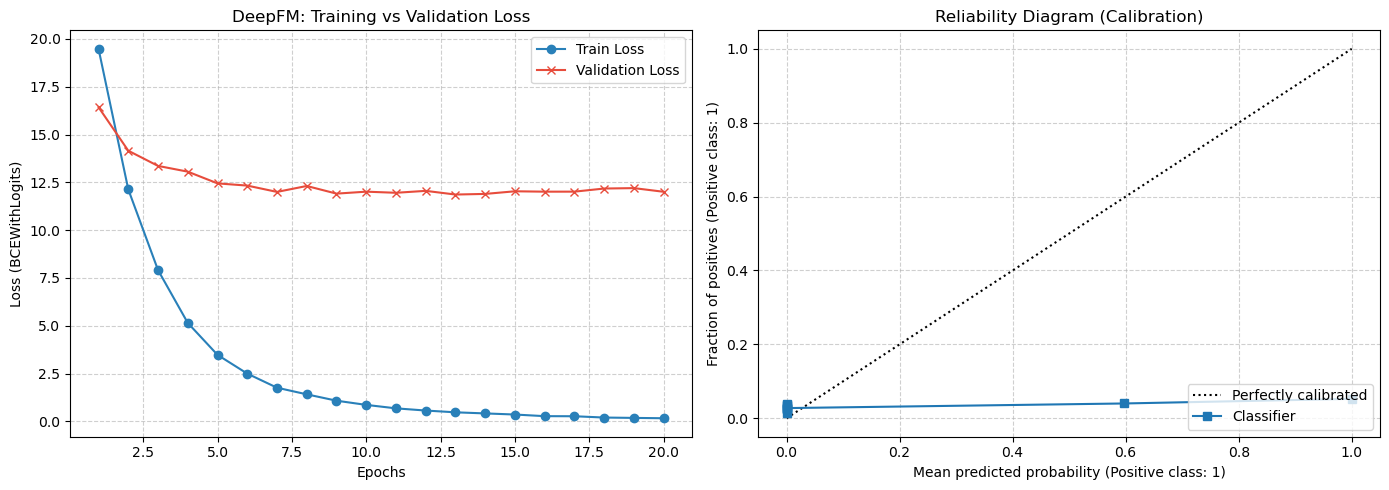

In [28]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, log_loss, f1_score

final_model = DeepFMCTR(
    sparse_cardinalities=sparse_cardinalities, 
    num_dense_features=len(dense_cols),
    dropout=0.296
).to(device)


all_preds, all_labels, train_loss, val_loss = train(
    final_model, 
    lr=0.00591,             
    weight_decay=0.000135,  
    pos_weight_val=11.949,  
    epochs=20
)

# 3. Final Metrics Evaluation
all_labels = np.array(all_labels).astype(int)
binary_predxns = [1 if p >= 0.55 else 0 for p in all_preds]

print("\n" + "="*40)
print("FINAL OPTIMIZED DEEPFM METRICS")
print("="*40)
print(f"ROC-AUC:          {roc_auc_score(all_labels, all_preds):.4f}")
print(f"PR-AUC:           {average_precision_score(all_labels, all_preds):.4f}")
print(f"Accuracy:         {accuracy_score(all_labels, binary_predxns):.4f}")
print(f"LogLoss:          {log_loss(all_labels, all_preds):.4f}")
print(f"F1 Score:         {f1_score(all_labels, binary_predxns):.4f}")
print("="*40)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(range(1, len(train_loss)+1), train_loss, label='Train Loss', color='#2980b9', marker='o')
ax1.plot(range(1, len(val_loss)+1), val_loss, label='Validation Loss', color='#e74c3c', marker='x')
ax1.set_title('DeepFM: Training vs Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (BCEWithLogits)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)


CalibrationDisplay.from_predictions(all_labels, all_preds, n_bins=10, ax=ax2, strategy='quantile')
ax2.set_title('Reliability Diagram (Calibration)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The confidence score is Bad, as per the plot for my implementation. I tried using Optuna for various ranges, but, I have obtained, ROC AUC of 0.59.  Also, The confidence score is very less. 

In real world, the Deep Factorisation Machine is supposed to do better. 